# Eilenberger Equation: Clean-Limit Quasiclassical Theory

The **Eilenberger equation** is the quasiclassical transport equation for
superconductors in the **clean (ballistic) limit**, where the mean free path
$\ell$ is much larger than the coherence length $\xi$. It occupies the middle
tier in the quasiclassical hierarchy: more general than Usadel (diffusive limit)
but far cheaper than full BdG (microscopic).

## Position in the Theory Hierarchy

$$
\underbrace{\text{BdG}}_{\lambda_F \sim 0.1\,\text{nm}}
\xrightarrow{\text{Gor'kov}}
\underbrace{\text{Eilenberger}}_{\text{ballistic},\ \ell \gg \xi}
\xrightarrow{\text{dirty limit}}
\underbrace{\text{Usadel}}_{\ell \ll \xi}
$$

| Regime | Condition | Equation | Key variable |
|:------:|:---------:|:--------:|:------------:|
| Microscopic | all $\lambda_F$ | BdG | $(u_n, v_n)$ |
| Clean | $\ell \gg \xi$ | **Eilenberger** | $\hat{g}(\hat{k}_F, x)$ |
| Dirty | $\ell \ll \xi$ | Usadel | $\hat{g}(x)$ |

The Eilenberger equation retains the **Fermi-surface angular dependence**
$\hat{k}_F$, which is averaged out in the Usadel limit.

## The Eilenberger Equation

For a 1D S/F heterostructure, the Eilenberger equation for the anomalous
quasiclassical propagator $f(\omega_n, \hat{k}_F, x)$ is:

$$
\hbar v_{F,x}\, \frac{\partial f}{\partial x}
= -2\bigl(\omega_n + i E_{\text{ex}}\bigr)\, f
  + 2\Delta(x)\, g
$$

with the normalization condition $g^2 + f \bar{f} = 1$, where
$v_{F,x} = v_F \cos\theta_{\hat{k}}$ is the Fermi velocity projected onto $\hat{x}$.

## Riccati Parametrization

Direct integration is unstable. The **Riccati parametrization**
(Schopohl & Maki, 1995) resolves this:

$$
f = \frac{2a}{1 + a\bar{a}}, \qquad
g = \frac{1 - a\bar{a}}{1 + a\bar{a}}
$$

The Riccati ODE is:

$$
\hbar v_{F,x}\, \frac{\partial a}{\partial x}
= -2\bigl(\omega_n + iE_{\text{ex}}\bigr)\, a
  + \Delta(x)\bigl(1 - a^2\bigr)
$$

| Property | Direct ($f$, $g$) | Riccati ($a$) |
|:---------|:--------:|:------:|
| Stability | Exponential blowup | Bounded: $|a| \le 1$ |
| Normalization | Must enforce $g^2 + f\bar{f} = 1$ | Automatic |
| Shooting | Needs matching | Stable single-direction sweep |

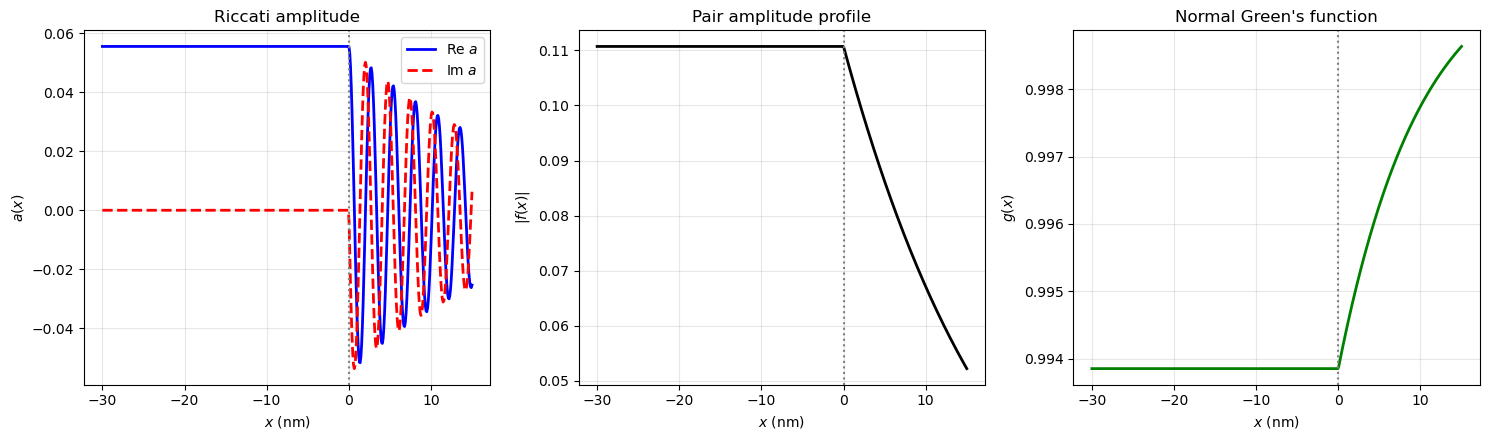

In [1]:
# Riccati integration of the Eilenberger equation in an S/F bilayer
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

import supermag
supermag.apply_theme("dark")

T = 4.0; omega_1 = np.pi * T; Delta_0 = 1.4; E_ex_K = 50 * 11.6
hbar_vF = 500.0; d_S = 30.0; d_F = 15.0

a_BCS = Delta_0 / (omega_1 + np.sqrt(omega_1**2 + Delta_0**2))
x_eval = np.linspace(-d_S, d_F, 500)

def rhs_bilayer(x, y):
    a = y[0] + 1j * y[1]
    Ex = E_ex_K if x >= 0 else 0.0
    D = Delta_0 if x < 0 else 0.0
    da = (-2*(omega_1 + 1j*Ex)*a + D*(1 - a**2)) / hbar_vF
    return [da.real, da.imag]

sol = solve_ivp(rhs_bilayer, (-d_S, d_F), [a_BCS, 0.0], t_eval=x_eval,
                rtol=1e-10, atol=1e-12, method='RK45')
a_c = sol.y[0] + 1j * sol.y[1]
f_anom = 2 * a_c / (1 + np.abs(a_c)**2)
g_norm = (1 - np.abs(a_c)**2) / (1 + np.abs(a_c)**2)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
axes[0].plot(sol.t, sol.y[0], 'b-', lw=2, label=r'Re $a$')
axes[0].plot(sol.t, sol.y[1], 'r--', lw=2, label=r'Im $a$')
axes[0].axvline(0, ls=':', color='grey')
axes[0].set_xlabel('$x$ (nm)'); axes[0].set_ylabel('$a(x)$')
axes[0].set_title('Riccati amplitude'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(sol.t, np.abs(f_anom), 'k-', lw=2)
axes[1].axvline(0, ls=':', color='grey')
axes[1].set_xlabel('$x$ (nm)'); axes[1].set_ylabel(r'$|f(x)|$')
axes[1].set_title('Pair amplitude profile'); axes[1].grid(True, alpha=0.3)

axes[2].plot(sol.t, g_norm, 'g-', lw=2)
axes[2].axvline(0, ls=':', color='grey')
axes[2].set_xlabel('$x$ (nm)'); axes[2].set_ylabel(r'$g(x)$')
axes[2].set_title("Normal Green's function"); axes[2].grid(True, alpha=0.3)
fig.tight_layout(); plt.show()

### SUPERMag Eilenberger Solver

The `supermag.eilenberger.solve()` function wraps the C++ Riccati integration
with Gauss-Legendre angular averaging into a single call.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import supermag

Tc0, d_S, d_F, xi_S, E_ex = 9.2, 30.0, 15.0, 38.0, 50.0

x_api, f_api = supermag.eilenberger.solve(Tc0, d_S, d_F, xi_S, E_ex, n_grid=500)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(x_api, f_api, 'k-', lw=2, label='supermag.eilenberger')
axes[0].axvline(0, ls=':', color='grey', alpha=0.5)
axes[0].set_xlabel('$ (nm)'); axes[0].set_ylabel(r'$|f(x)|$')
axes[0].set_title('Eilenberger (C++ path)'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

for eex, col, ls in [(10, '#2ca02c', '--'), (50, '#1f77b4', '-'), (200, '#d62728', ':')]:
    x_e, f_e = supermag.eilenberger.solve(Tc0, d_S, d_F, xi_S, eex, n_grid=400)
    axes[1].plot(x_e, f_e, color=col, ls=ls, lw=2, label=f'{{ex}}$ = {eex} meV')
axes[1].axvline(0, ls=':', color='grey', alpha=0.5)
axes[1].set_xlabel('$ (nm)'); axes[1].set_ylabel(r'$|f(x)|$')
axes[1].set_title('Exchange-field sweep (API)'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
fig.tight_layout(); plt.show()

## Fermi-Surface Averaging

Unlike Usadel, the Eilenberger propagator retains the direction $\hat{k}_F$.
Observable quantities require averaging over the Fermi surface:

$$
\langle f \rangle(x) = \frac{1}{2} \int_0^\pi f(\omega_n, \theta, x)\, \sin\theta\, d\theta
$$

For right-movers ($\cos\theta > 0$) and left-movers ($\cos\theta < 0$),
the Riccati equation is integrated in opposite directions.

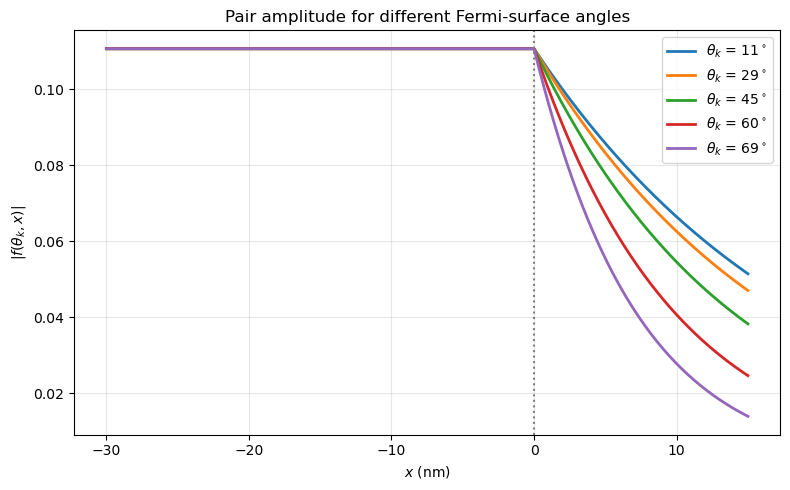

In [2]:
# Fermi-surface angle dependence of the pair amplitude
import numpy as np, matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

T = 4.0; omega_1 = np.pi*T; Delta_0 = 1.4; E_ex_K = 50*11.6
hbar_vF_base = 500.0; d_S = 30.0; d_F = 15.0

fig, ax = plt.subplots(figsize=(8, 5))
for theta_k in [0.2, 0.5, np.pi/4, np.pi/3, 1.2]:
    hbar_vFx = hbar_vF_base * np.cos(theta_k)
    if abs(hbar_vFx) < 1e-6: continue
    a_BCS = Delta_0 / (omega_1 + np.sqrt(omega_1**2 + Delta_0**2))
    x_eval = np.linspace(-d_S, d_F, 400)
    def rhs(x, y, vFx=hbar_vFx):
        a = y[0]+1j*y[1]; Ex = E_ex_K if x>=0 else 0.0; D = Delta_0 if x<0 else 0.0
        da = (-2*(omega_1+1j*Ex)*a + D*(1-a**2))/vFx
        return [da.real, da.imag]
    sol = solve_ivp(rhs, (-d_S, d_F), [a_BCS, 0.0], t_eval=x_eval, rtol=1e-10, atol=1e-12)
    a_c = sol.y[0]+1j*sol.y[1]
    f_val = 2*a_c/(1+np.abs(a_c)**2)
    ax.plot(sol.t, np.abs(f_val), lw=2, label=rf'$\theta_k$ = {np.degrees(theta_k):.0f}$^\circ$')
ax.axvline(0, ls=':', color='grey')
ax.set_xlabel('$x$ (nm)'); ax.set_ylabel(r'$|f(\theta_k,x)|$')
ax.set_title('Pair amplitude for different Fermi-surface angles')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## Clean Limit vs. Dirty Limit

The Usadel equation is recovered from Eilenberger in the dirty limit $\ell \ll \xi$.

| Property | Eilenberger (clean) | Usadel (dirty) |
|:---------|:-------------------:|:--------------:|
| Mean free path | $\ell \gg \xi$ | $\ell \ll \xi$ |
| Angular dep. | Full $\hat{k}_F$ | Isotropic |
| Coherence length | $\xi_0 = \hbar v_F/(2\pi T_c)$ | $\xi_D = \sqrt{\hbar D/(2\pi T_c)}$ |
| Numerical cost | $\mathcal{O}(N_\theta \times N_x)$ | $\mathcal{O}(N_x)$ |

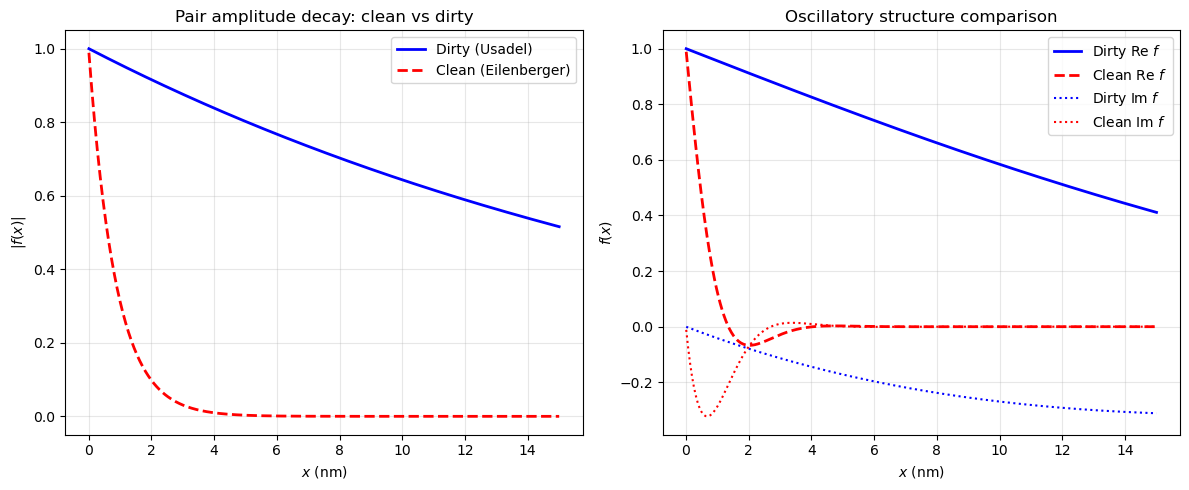

In [3]:
# Comparison: clean (Eilenberger) vs dirty (Usadel) pair amplitude decay in F
import numpy as np, matplotlib.pyplot as plt
x = np.linspace(0.01, 15, 500)
E_ex_K = 50*11.6; T = 4.0; omega_1 = np.pi*T
hbar_D_kB = 3.04e5; hbar_vF = 500.0

kappa_dirty = np.sqrt(2*(omega_1+1j*E_ex_K)/hbar_D_kB)
f_dirty = np.exp(-kappa_dirty*x)
xi_clean = hbar_vF/(2*E_ex_K)
f_clean = np.exp(-(1+1j)*x/(2*xi_clean))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(x, np.abs(f_dirty), 'b-', lw=2, label='Dirty (Usadel)')
axes[0].plot(x, np.abs(f_clean), 'r--', lw=2, label='Clean (Eilenberger)')
axes[0].set_xlabel('$x$ (nm)'); axes[0].set_ylabel(r'$|f(x)|$')
axes[0].set_title('Pair amplitude decay: clean vs dirty')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(x, f_dirty.real, 'b-', lw=2, label='Dirty Re $f$')
axes[1].plot(x, f_clean.real, 'r--', lw=2, label='Clean Re $f$')
axes[1].plot(x, f_dirty.imag, 'b:', lw=1.5, label='Dirty Im $f$')
axes[1].plot(x, f_clean.imag, 'r:', lw=1.5, label='Clean Im $f$')
axes[1].set_xlabel('$x$ (nm)'); axes[1].set_ylabel(r'$f(x)$')
axes[1].set_title('Oscillatory structure comparison')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
fig.tight_layout(); plt.show()

In [ ]:
# Clean vs Dirty comparison using both supermag solvers
import numpy as np
import matplotlib.pyplot as plt
import supermag

Tc0, d_S, d_F = 9.2, 30.0, 15.0
xi_S, xi_F, E_ex = 38.0, 1.0, 50.0

x_eil, f_eil = supermag.eilenberger.solve(Tc0, d_S, d_F, xi_S, E_ex, n_grid=400)
x_usa, Delta_usa = supermag.usadel.solve(Tc0, d_S, d_F, xi_S, xi_F, E_ex, n_grid=400)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x_eil, f_eil / max(f_eil), 'r-', lw=2, label='Eilenberger (clean)')
ax.plot(x_usa, Delta_usa / max(Delta_usa), 'b--', lw=2, label='Usadel (dirty)')
ax.axvline(0, ls=':', color='grey', alpha=0.5)
ax.set_xlabel('$ (nm)'); ax.set_ylabel('Normalised pair amplitude')
ax.set_title('Clean vs Dirty limit - composable C++ path')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## Numerical Implementation Notes

The C++ implementation in `solvers/eilenberger.cpp`, exposed via
`supermag.eilenberger.solve()`, uses the Riccati parametrization for stability. The key algorithmic steps are:

1. **Spatial discretization**: Uniform grid spanning S and F layers
2. **Angular quadrature**: Gauss-Legendre over $\theta \in [0, \pi]$
3. **Directional integration**: Right-movers left-to-right, left-movers right-to-left
4. **Matsubara sum**: Sum over $\omega_n$ for self-consistency
5. **Self-consistency loop**: Iterate $\Delta(x)$ until convergence

## References

1. Eilenberger, G., "Transformation of Gorkov's equation for type II superconductors into transport-like equations," Z. Physik **214**, 195 (1968).
2. Schopohl, N. & Maki, K., "Quasiparticle spectrum around a vortex line in a d-wave superconductor," Phys. Rev. B **52**, 490 (1995).
3. Eschrig, M., "Distribution functions in nonequilibrium theory of superconductivity," Phys. Rev. B **61**, 9061 (2000).
4. Belzig, W. et al., "Quasiclassical Green's function approach to mesoscopic superconductivity," Superlattices Microstruct. **25**, 1251 (1999).